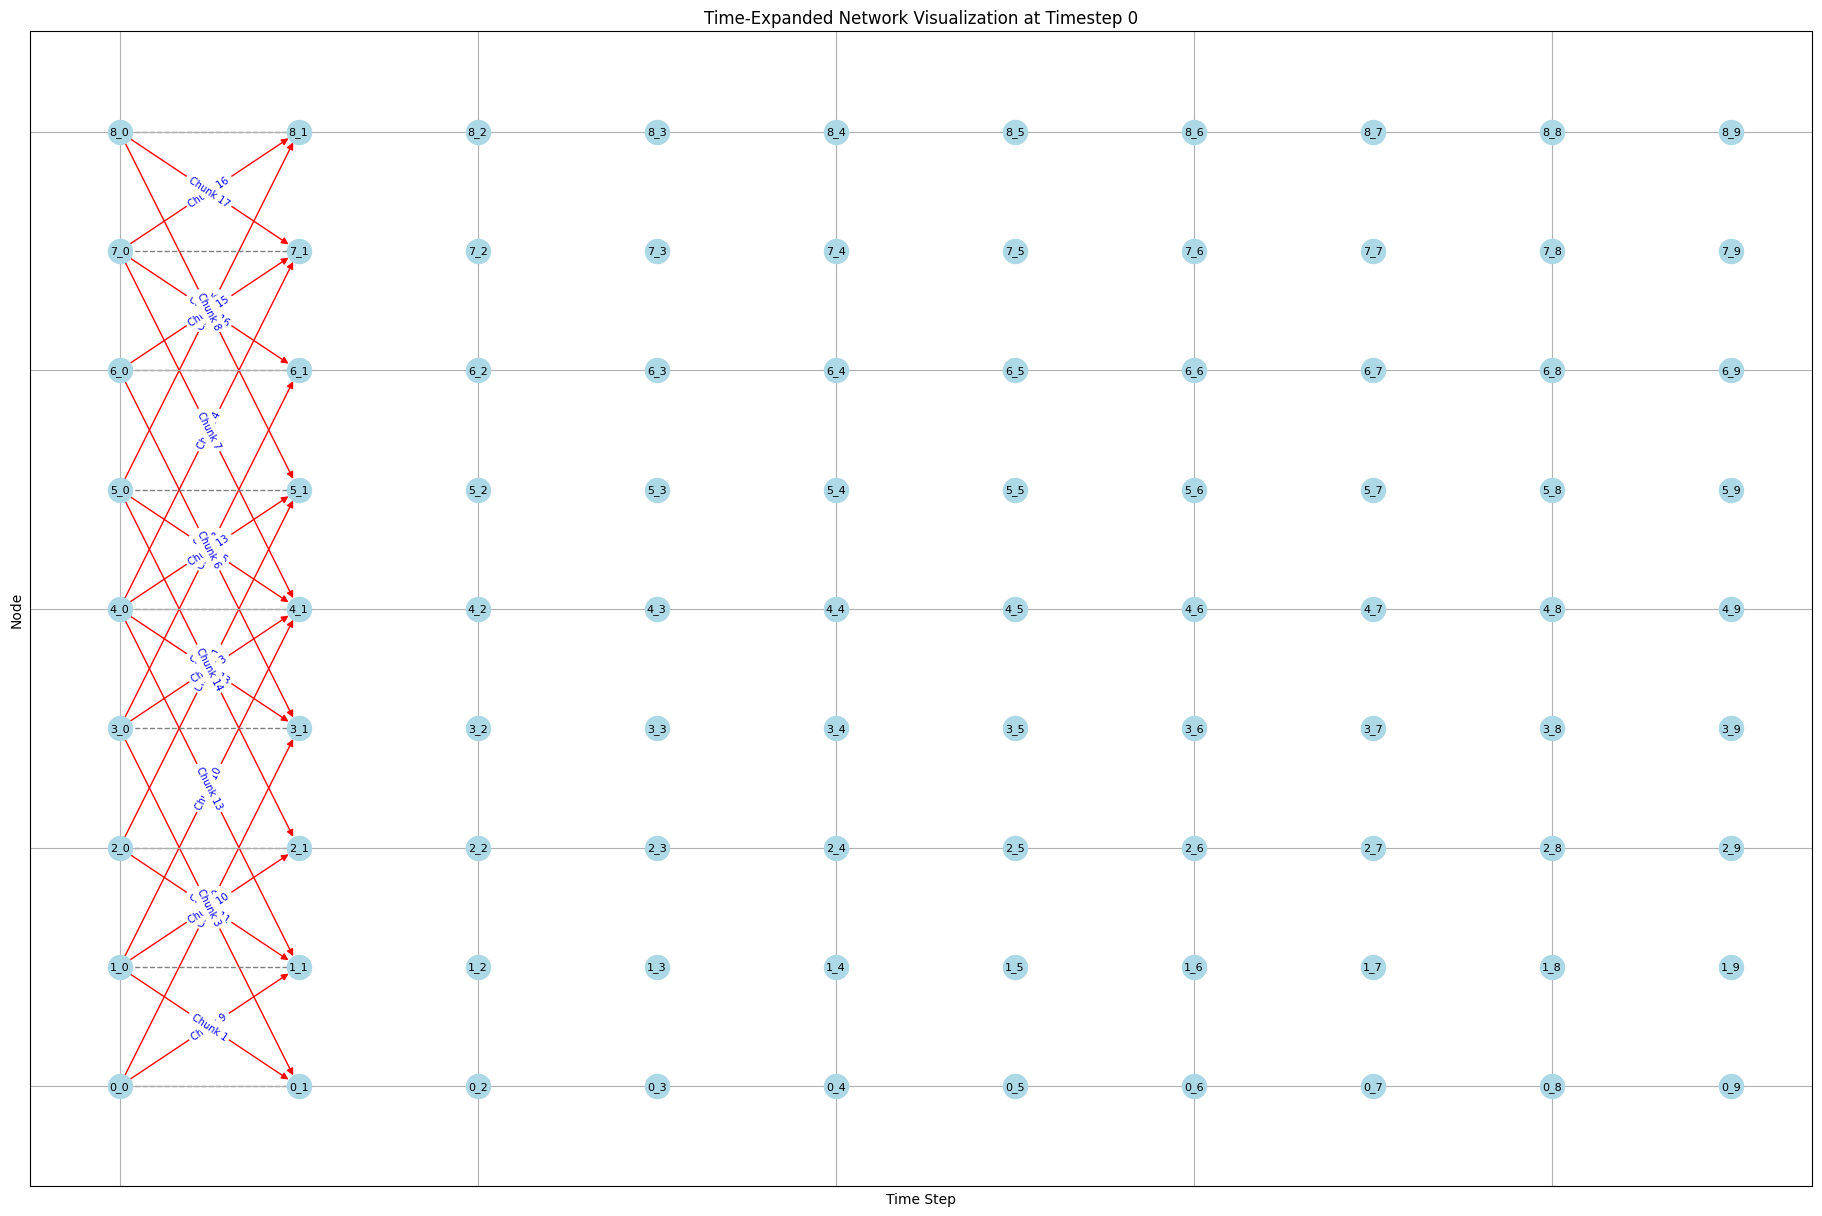

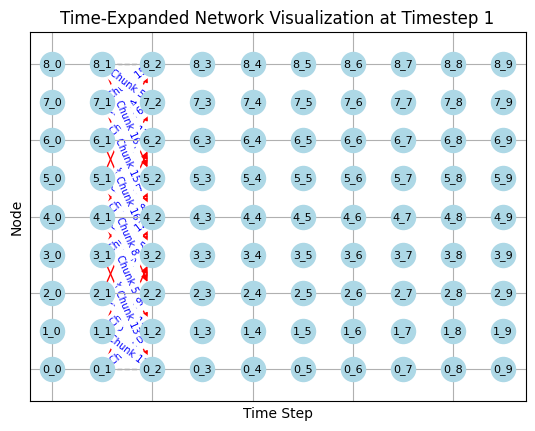

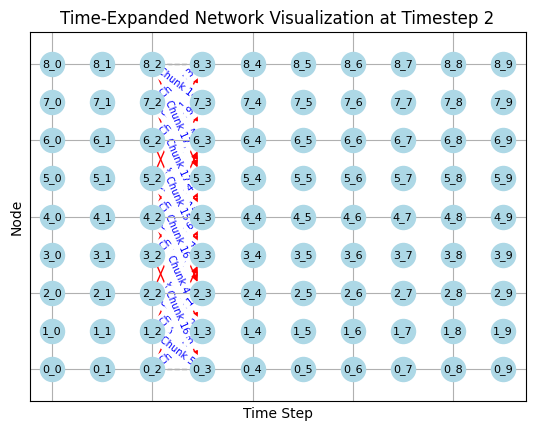

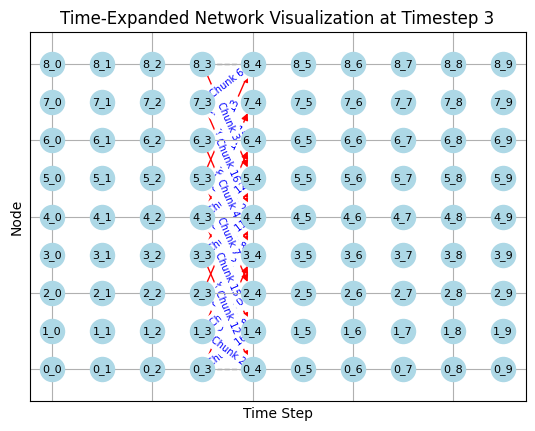

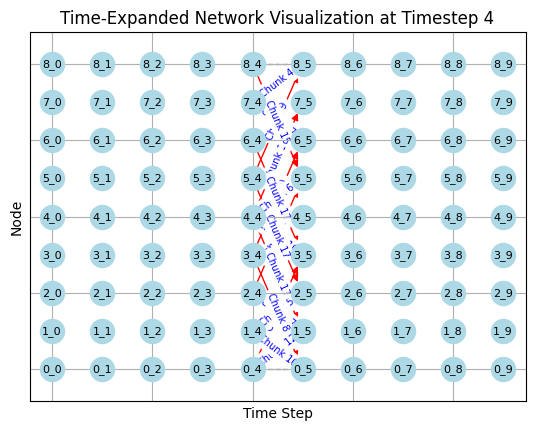

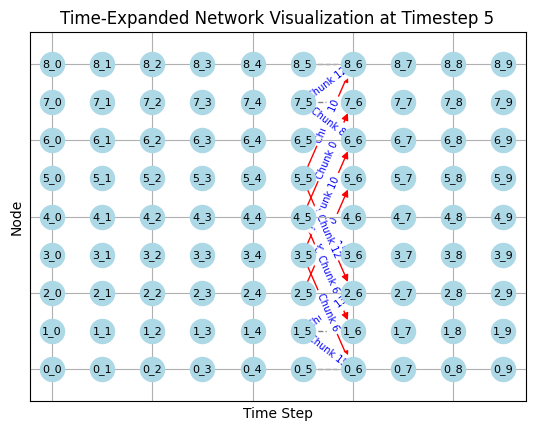

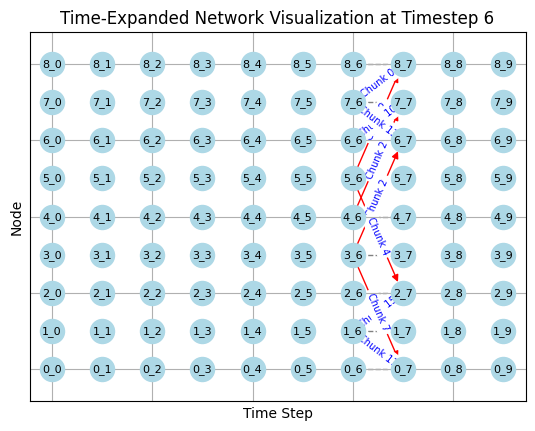

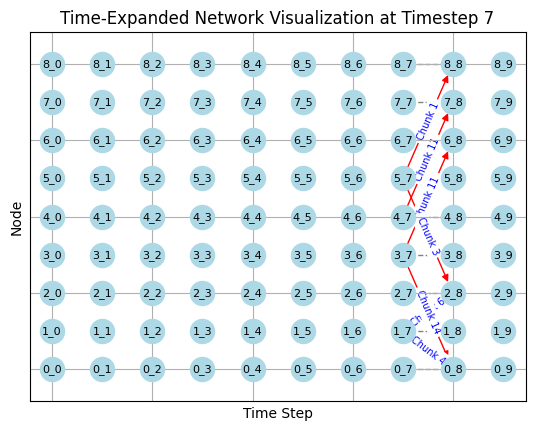

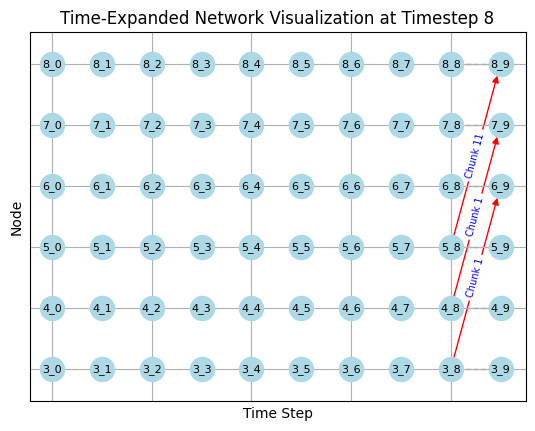

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import csv
import time

flow_data = []

with open("gpu_3_link_500_bw_50_chunk_1024_chunk_coll_2.csv", "r") as csvfile:
    csvreader = csv.reader(csvfile)
    for row in csvreader:
        for i in range(len(row)):
            row[i] = int(row[i])
        flow_data.append(row)

total_time_steps = sorted(set(t for t, _, _, _ in flow_data))

def visualize_timestep(timestep: int):
    # Extract unique time steps, nodes, and chunk IDs
    time_flow_data = [i for i in flow_data if i[0] == timestep]
    time_steps = sorted(set(t for t, _, _, _ in time_flow_data))
    nodes = sorted(set(n for _, _, n, _ in time_flow_data) | set(n for _, _, _, n in time_flow_data))
    chunk_ids = sorted(set(c for _, c, _, _ in time_flow_data))

    G = nx.DiGraph()

    # Add temporal nodes
    for t in total_time_steps + [max(total_time_steps) + 1]:  # Include the last time step for destinations
        for n in nodes:
            G.add_node(f"{n}_{t}", node=n, time=t)

    # Add edges based on flow_data
    for t, chunk_id, src, dst in time_flow_data:
        G.add_edge(f"{src}_{t}", f"{dst}_{t+1}", chunk=chunk_id)

    # Add holding edges
    for t in time_steps:
        for n in nodes:
            G.add_edge(f"{n}_{t}", f"{n}_{t+1}", hold=True)

    # Set positions: Time on x-axis, Node ID on y-axis
    pos = {}
    for node in G.nodes():
        n, t = node.split('_')
        pos[node] = (int(t), int(n))

    return (G, pos)

# Set up the figure once
plt.figure(figsize=(23, 15))

for i in range(len(total_time_steps)):
    G, pos = visualize_timestep(i)
    
    # Clear the current axes instead of the whole figure
    plt.clf()  
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=300, node_color='lightblue')

    # Draw edges
    edges = G.edges(data=True)
    edge_colors = ['red' if 'chunk' in data else 'gray' for _, _, data in edges]
    edge_styles = ['solid' if 'chunk' in data else 'dashed' for _, _, data in edges]

    # Separate edge lists based on style
    chunk_edges = [(u, v) for u, v, data in edges if 'chunk' in data]
    hold_edges = [(u, v) for u, v, data in edges if 'hold' in data]

    # Draw chunk movement edges
    nx.draw_networkx_edges(
        G, pos, edgelist=chunk_edges, edge_color='red', style='solid', arrows=True
    )

    # Draw holding edges
    nx.draw_networkx_edges(
        G, pos, edgelist=hold_edges, edge_color='gray', style='dashed', arrows=False
    )

    # Draw labels
    nx.draw_networkx_labels(G, pos, font_size=8)

    # Annotate edges with chunk IDs
    edge_labels = {}
    for u, v, data in edges:
        if 'chunk' in data:
            edge_labels[(u, v)] = f"Chunk {data['chunk']}"
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='blue', font_size=7)

    # Set plot labels and title
    plt.xlabel('Time Step')
    plt.ylabel('Node')
    plt.title(f'Time-Expanded Network Visualization at Timestep {i}')
    plt.grid(True)

    # Show the plot
    plt.draw()  # Redraw the current figure
    plt.pause(0.1)  # Optional pause for dynamic viewing

# Final display to keep the last plot visible
plt.show()
    